# Forecasting BNS strong lensing rates

Forecast the number of detectable strongly lensed gravitational-wave (GW) events from
binary neutron star (BNS) mergers, for different GW detector networks. 


In [1]:
import numpy as np
from scipy.integrate import trapz
from astropy.cosmology import Planck18 as cosmo

from gw_lensing.utils.constants import *
from gw_lensing.utils import gwutils
from gw_lensing.gw_population import gwpop
from gw_lensing.utils import utils
from gw_lensing.detectors import sensitivity_curves as sc
from gw_lensing.gw_rates import rates
from gw_lensing.lensing_rates import sis_rates as sisrates
from gw_lensing.lens_models import sis
from gw_lensing.optical_depth import sis_optical_depth as sistau


In [2]:
#PLOTTING MODULES
import matplotlib.colors as mc
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
fontSZ = 17
fontSz = 15
fontsz = 13
fontssz = 11

new_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

import os
dir_base = os.getcwd()
dir_out = dir_base + "/plots/"
os.makedirs(dir_out, exist_ok=True)


## Binary neutron star population model

We use standard assumptions for the BNS population:
- Merger rate density following the same Madau & Dickinson (2014)-like star-formation
  history assumed for BBH (no dedicated BNS redshift-evolution fit exists), normalized
  to the local rate $R_0$ at $z=0$.
- Local rate: GWTC-5.0's updated BNS merger-rate constraint (arXiv:2605.27226, Table 2)
  -- PixelPop $23.4^{+54.7}_{-18.2}$, FullPop $59.3^{+95.4}_{-43.9}$, Joint 90\% CI
  $[5.1, 154.7]\,\mathrm{yr}^{-1}\mathrm{Gpc}^{-3}$. We take
  $R_0 = \sqrt{5.1\times154.7}\approx 28.1\,\mathrm{yr}^{-1}\mathrm{Gpc}^{-3}$
  (geometric mean of the Joint CI; no pipeline is preferred by the paper for BNS) as
  fiducial, with $R_0^{\rm low/up}$ the Joint CI bounds. This is a substantial
  tightening vs. the previous GWTC-3 estimate (320, 90\% CI $[10,1700]$).
- Uniform component masses $m_1, m_2 \sim \mathrm{Uniform}(1.0, 2.2)\,M_\odot$
  with $m_2 \le m_1$ (arXiv:2111.03634, GWTC-5.0 ran no dedicated BNS mass-model fit).


In [3]:
from fiducial_universe_gwtc5 import *


In [4]:
def pz_bns(z):
    return gwpop.rate_z(z,zp_fid,alpha_z_fid,beta_fid)


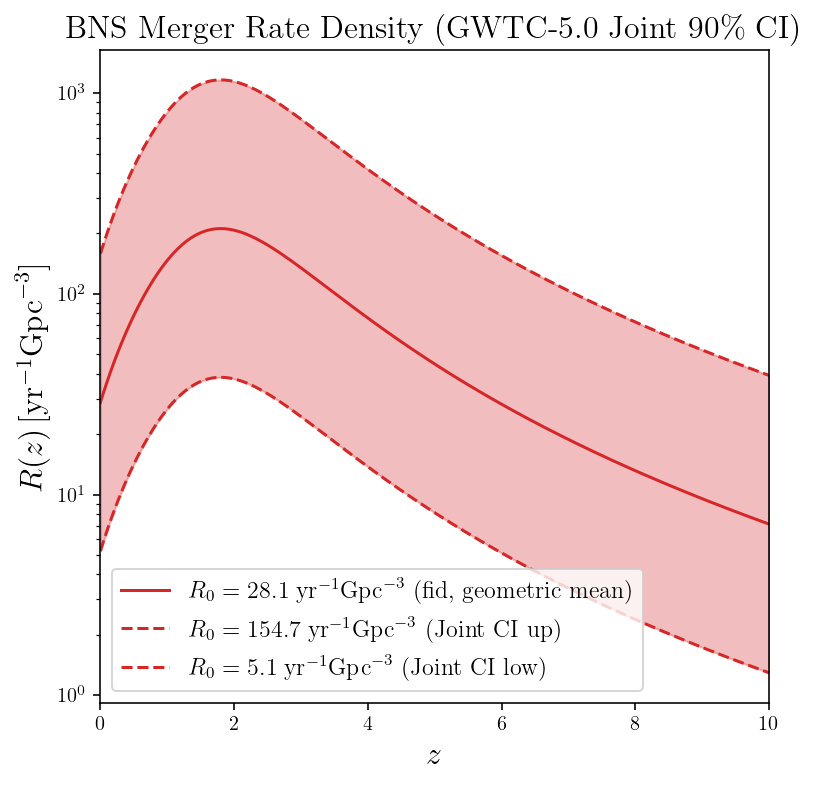

In [5]:
zs = np.linspace(0.01, 10., 200)
Rz_fid = R0_bns_fid * pz_bns(zs)
Rz_up = R0_bns_up * pz_bns(zs)
Rz_low = R0_bns_low * pz_bns(zs)

plt.figure(figsize=(6,6))
plt.fill_between(zs,Rz_low,Rz_up,color=new_colors[3],alpha=0.3)
plt.plot(zs,Rz_fid,color=new_colors[3],label=fr'$R_0={R0_bns_fid:.1f}\ \mathrm{{yr}}^{{-1}} \mathrm{{Gpc}}^{{-3}}$ (fid, geometric mean)')
plt.plot(zs,Rz_up,color=new_colors[3],ls='--',label=fr'$R_0={R0_bns_up:.1f}\ \mathrm{{yr}}^{{-1}} \mathrm{{Gpc}}^{{-3}}$ (Joint CI up)')
plt.plot(zs,Rz_low,color=new_colors[3],ls='--',label=fr'$R_0={R0_bns_low:.1f}\ \mathrm{{yr}}^{{-1}} \mathrm{{Gpc}}^{{-3}}$ (Joint CI low)')
plt.xlabel(r'$z$',fontsize=16)
plt.ylabel(r'$R(z) \, [\mathrm{yr}^{-1} \mathrm{Gpc}^{-3}]$',fontsize=16)
plt.xlim(0,10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.title('BNS Merger Rate Density (GWTC-5.0 Joint 90\% CI)',fontsize=16)
plt.savefig(dir_out+'bns_merger_rate_density.pdf', bbox_inches='tight', transparent=True)
plt.show()


In [6]:
def pm1_bns(mass_1):
    return utils.powerlaw(mass_1,mmin_bns_fid,mmax_bns_fid,0.)

def pq_bns(q):
    return utils.powerlaw(q,0.,1.,bq_bns_fid)

def pm2_bns(mass_2,mass_1):
    q = mass_2/mass_1
    return pq_bns(q)/mass_1


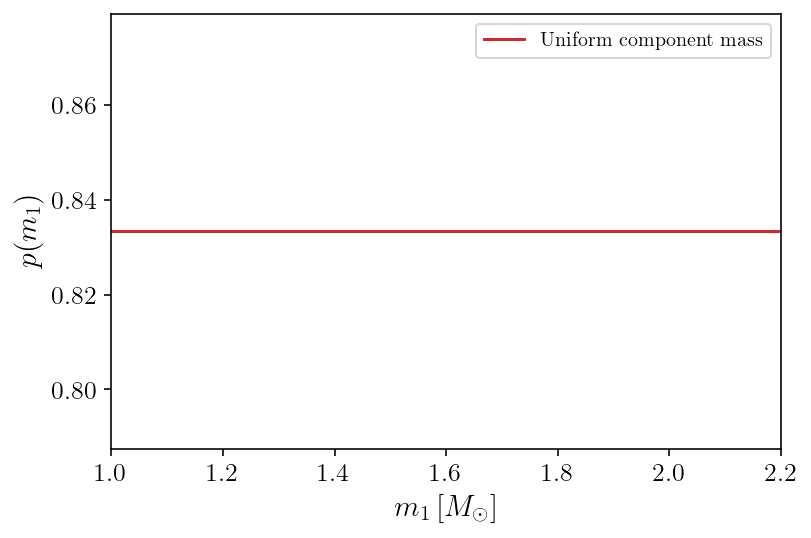

In [7]:
ms = np.linspace(mmin_bns_fid, mmax_bns_fid, 500)
pm = pm1_bns(ms)

plt.plot(ms, pm, label='Uniform component mass', color=new_colors[3])
plt.xlabel(r'$m_1\,[M_\odot]$',fontsize=fontSz)
plt.ylabel(r'$p(m_1)$',fontsize=fontSz)
plt.tick_params(axis='both', which='major', labelsize=fontsz)
plt.xlim(mmin_bns_fid,mmax_bns_fid)
plt.legend()
plt.show()


## GW detectors

In [8]:
Sn_O4, fmin_O4, fmax_O4 = sc.detector_psd('O4')
Sn_Aplus, fmin_Aplus, fmax_Aplus = sc.detector_psd('A+')
Sn_Asharp, fmin_Asharp, fmax_Asharp = sc.detector_psd('A#')
Sn_CE, fmin_CE, fmax_CE = sc.detector_psd('CE-40')
based = 'ground'
snr_th = 8.
Tobs = Tobs_fid


## Binary neutron star merger and detection rates

We first compute the number of BNS mergers per year (all-sky, all-redshift), then the
expected number of *detections* per year for each detector network, for the fiducial
rate and its 90\% CI bounds.

In [9]:
zmin = 0.01
zmax = 10.
n_m1 = 50 #number of primary-mass bins
n_m2 = 10 #number of secondary-mass bins
n_z = 50 #number of redshift bins

norm_m1_bns = 1. #pm1_bns is already normalized (uniform distribution)

Nbns_fid = np.round(rates.Ncbc(pz_bns,R0_bns_fid,H0_fid,Om0_fid,Tobs,zmin,zmax,n_z),2)
Nbns_up = np.round(rates.Ncbc(pz_bns,R0_bns_up,H0_fid,Om0_fid,Tobs,zmin,zmax,n_z),2)
Nbns_low = np.round(rates.Ncbc(pz_bns,R0_bns_low,H0_fid,Om0_fid,Tobs,zmin,zmax,n_z),2)
print('BNSs per year (fid): ',Nbns_fid)
print('BNSs per year (up): ',Nbns_up)
print('BNSs per year (low): ',Nbns_low)


BNSs per year (fid):  93926.19
BNSs per year (up):  517305.14
BNSs per year (low):  17054.02


In [10]:
detectors = {
    'O4': (Sn_O4,fmin_O4,fmax_O4),
    'A+': (Sn_Aplus,fmin_Aplus,fmax_Aplus),
    'A#': (Sn_Asharp,fmin_Asharp,fmax_Asharp),
    'CE': (Sn_CE,fmin_CE,fmax_CE),
}

Nbns_det_fid, Nbns_det_up, Nbns_det_low = {}, {}, {}
for name,(Sn,fmin,fmax) in detectors.items():
    Nbns_det_fid[name] = rates.Ndet(pz_bns,pm1_bns,pm2_bns,R0_bns_fid,norm_m1_bns,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,mmin_bns_fid,mmax_bns_fid,n_m1,n_m2,zmin,zmax,n_z)
    Nbns_det_up[name] = rates.Ndet(pz_bns,pm1_bns,pm2_bns,R0_bns_up,norm_m1_bns,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,mmin_bns_fid,mmax_bns_fid,n_m1,n_m2,zmin,zmax,n_z)
    Nbns_det_low[name] = rates.Ndet(pz_bns,pm1_bns,pm2_bns,R0_bns_low,norm_m1_bns,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,mmin_bns_fid,mmax_bns_fid,n_m1,n_m2,zmin,zmax,n_z)
    print(f'Detected BNSs per year ({name}, fid/low/up): {Nbns_det_fid[name]:.3g} / {Nbns_det_low[name]:.3g} / {Nbns_det_up[name]:.3g}')


Detected BNSs per year (O4, fid/low/up): 0.364 / 0.0661 / 2
Detected BNSs per year (A+, fid/low/up): 2.29 / 0.415 / 12.6
Detected BNSs per year (A#, fid/low/up): 17.8 / 3.24 / 98.3
Detected BNSs per year (CE, fid/low/up): 1.17e+04 / 2.13e+03 / 6.45e+04


## Strong Lensing GW rates

As for the BBH case, we model the entire population of lenses using the
[Tinker et al. 2008](https://arxiv.org/abs/0803.2706) halo mass function implemented in
[colossus](https://bdiemer.bitbucket.io/colossus/lss_mass_function.html#lss.mass_function.modelTinker08).
The lenses are chosen to have a Singular Isothermal Sphere (SIS) profile.

In [11]:
log10MLmin = 6
log10MLmax = 16
nMLs = 100
nzLs = 100


The rate of lensed BNS, not necessarily detected, can be computed as

In [12]:
Nbns_lens_fid = sisrates.Ncbc_lens(pz_bns,R0_bns_fid,H0_fid,Om0_fid,Tobs,log10MLmin,log10MLmax,nMLs,nzLs,zmin,zmax,n_z)
Nbns_lens_up = sisrates.Ncbc_lens(pz_bns,R0_bns_up,H0_fid,Om0_fid,Tobs,log10MLmin,log10MLmax,nMLs,nzLs,zmin,zmax,n_z)
Nbns_lens_low = sisrates.Ncbc_lens(pz_bns,R0_bns_low,H0_fid,Om0_fid,Tobs,log10MLmin,log10MLmax,nMLs,nzLs,zmin,zmax,n_z)

print('BNSs per year (fid): ',Nbns_fid)
print('Lensed BNSs per year (fid): ',Nbns_lens_fid)
print('Lensed fraction (fid): ',Nbns_lens_fid/Nbns_fid)
print('Lensed BNSs per year (low/up): ',Nbns_lens_low,'/',Nbns_lens_up)


BNSs per year (fid):  93926.19
Lensed BNSs per year (fid):  140.67604002541344
Lensed fraction (fid):  0.0014977296537356985
Lensed BNSs per year (low/up):  25.542303783059598 / 774.7832147528077


## Strongly lensed GW image detection rates

We compute the number of detectable lensed BNS events for different detector networks,
for the primary and secondary SIS images separately (including the magnification bias).

In [13]:
nys = 50


Brightest image

In [ ]:
Nbns_lens_mup_fid, Nbns_lens_mup_up, Nbns_lens_mup_low = {}, {}, {}
for name,(Sn,fmin,fmax) in detectors.items():
    Nbns_lens_mup_fid[name] = sisrates.Ndet_lens_mu(pz_bns,pm1_bns,pm2_bns,R0_bns_fid,norm_m1_bns,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,log10MLmin,log10MLmax,nMLs,nzLs,sis.mu_plus,nys,mmin_bns_fid,mmax_bns_fid,n_m1,n_m2,zmin,zmax,n_z)
    Nbns_lens_mup_up[name] = sisrates.Ndet_lens_mu(pz_bns,pm1_bns,pm2_bns,R0_bns_up,norm_m1_bns,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,log10MLmin,log10MLmax,nMLs,nzLs,sis.mu_plus,nys,mmin_bns_fid,mmax_bns_fid,n_m1,n_m2,zmin,zmax,n_z)
    Nbns_lens_mup_low[name] = sisrates.Ndet_lens_mu(pz_bns,pm1_bns,pm2_bns,R0_bns_low,norm_m1_bns,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,log10MLmin,log10MLmax,nMLs,nzLs,sis.mu_plus,nys,mmin_bns_fid,mmax_bns_fid,n_m1,n_m2,zmin,zmax,n_z)
    print(f'Detected lensed primary-image BNSs per year ({name}, fid/low/up): {Nbns_lens_mup_fid[name]:.3g} / {Nbns_lens_mup_low[name]:.3g} / {Nbns_lens_mup_up[name]:.3g}')


Detected lensed primary-image BNSs per year (O4, fid/low/up): 9.21e-06 / 1.67e-06 / 5.07e-05
Detected lensed primary-image BNSs per year (A+, fid/low/up): 0.00032 / 5.8e-05 / 0.00176


Second brightest image

In [ ]:
Nbns_lens_mum_fid, Nbns_lens_mum_up, Nbns_lens_mum_low = {}, {}, {}
for name,(Sn,fmin,fmax) in detectors.items():
    Nbns_lens_mum_fid[name] = sisrates.Ndet_lens_mu(pz_bns,pm1_bns,pm2_bns,R0_bns_fid,norm_m1_bns,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,log10MLmin,log10MLmax,nMLs,nzLs,sis.mu_minus,nys,mmin_bns_fid,mmax_bns_fid,n_m1,n_m2,zmin,zmax,n_z)
    Nbns_lens_mum_up[name] = sisrates.Ndet_lens_mu(pz_bns,pm1_bns,pm2_bns,R0_bns_up,norm_m1_bns,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,log10MLmin,log10MLmax,nMLs,nzLs,sis.mu_minus,nys,mmin_bns_fid,mmax_bns_fid,n_m1,n_m2,zmin,zmax,n_z)
    Nbns_lens_mum_low[name] = sisrates.Ndet_lens_mu(pz_bns,pm1_bns,pm2_bns,R0_bns_low,norm_m1_bns,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,log10MLmin,log10MLmax,nMLs,nzLs,sis.mu_minus,nys,mmin_bns_fid,mmax_bns_fid,n_m1,n_m2,zmin,zmax,n_z)
    print(f'Detected lensed secondary-image BNSs per year ({name}, fid/low/up): {Nbns_lens_mum_fid[name]:.3g} / {Nbns_lens_mum_low[name]:.3g} / {Nbns_lens_mum_up[name]:.3g}')


In [ ]:
print('Fraction of detections that are lensed (fid), primary + secondary image:')
for name in detectors:
    frac = (Nbns_lens_mup_fid[name] + Nbns_lens_mum_fid[name]) / Nbns_det_fid[name]
    print(f'  {name}: {frac:.2e}')


## Results with Monte Carlo uncertainties

We can use Monte Carlo integration to compute the lensed detectability
\begin{equation}
I = \int f(x)p(x)dx = \left\langle f(x) \right\rangle = \frac{1}{N}\sum_{i=1}^N f(x_i)
\end{equation}

where $x_i$ are drawn from the distribution $p(x)$.


In [ ]:
from scipy.interpolate import interp1d


We interpolate the optical depth for a faster computation of the Monte Carlo rates, using
the Schechter velocity-dispersion function ([Choi et al. 2007](https://arxiv.org/abs/0706.1416))
for the galaxy lens population (same population used for the BBH forecast).

In [ ]:
n = 8e-3 * np.power(H0_fid/100,3) #Mpc^-3
sigmaS,alpha,beta = 161, 2.32, 2.67

zs = np.linspace(0.001,30,1000)
tau_int = interp1d(zs,sistau.tau_Schechter(zs,n,sigmaS,alpha,beta),bounds_error=False,fill_value=np.nan)


In [ ]:
Nmc = 1500

zmin_mc = 0.001
zmax_mc = 10.
n_z_mc = 50
zs_mc = np.linspace(zmin_mc,zmax_mc,n_z_mc)

Nbns_lens_mup_MC, err_Nbns_lens_mup_MC = {}, {}
Nbns_lens_mum_MC, err_Nbns_lens_mum_MC = {}, {}
for name,(Sn,fmin,fmax) in detectors.items():
    dN_mup_dz, err_mup_dz = sisrates.vdNdet_MC_lens_mu_dz(zs_mc,Nmc,pz_bns,pm1_bns,pq_bns,R0_bns_fid,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,tau_int,sis.mu_plus,zmin_mc,zmax_mc,mmin_bns_fid,mmax_bns_fid)
    Nbns_lens_mup_MC[name], err_Nbns_lens_mup_MC[name] = trapz(dN_mup_dz,zs_mc), trapz(err_mup_dz,zs_mc)

    dN_mum_dz, err_mum_dz = sisrates.vdNdet_MC_lens_mu_dz(zs_mc,Nmc,pz_bns,pm1_bns,pq_bns,R0_bns_fid,H0_fid,Om0_fid,Tobs,snr_th,Sn,fmin,fmax,based,tau_int,sis.mu_minus,zmin_mc,zmax_mc,mmin_bns_fid,mmax_bns_fid)
    Nbns_lens_mum_MC[name], err_Nbns_lens_mum_MC[name] = trapz(dN_mum_dz,zs_mc), trapz(err_mum_dz,zs_mc)

    print(f'Detected lensed primary image of BNSs per year ({name}) (SIS, Schechter): {Nbns_lens_mup_MC[name]:.2e} +/- {err_Nbns_lens_mup_MC[name]:.2e}')
    print(f'Detected lensed secondary image of BNSs per year ({name}) (SIS, Schechter): {Nbns_lens_mum_MC[name]:.2e} +/- {err_Nbns_lens_mum_MC[name]:.2e}')
